# Task 2.1 — Dataset Selection and Setup
**Paper:** DynaMMo: Mining and Summarization of Coevolving Sequences with Missing Values  
**Authors:** Li, McCann, Pollard, Faloutsos — KDD 2009  

This notebook generates the synthetic dataset used in all Task 2 experiments.

| Variable | Shape | NaN? | Role |
|---|---|---|---|
| `X_true` | (300, 8) | ❌ No | Complete ground truth — **MODEL NEVER SEES THIS** |
| `X_miss` | (300, 8) | ✅ Yes | Training input — **ONLY input to `model.fit()`** |
| `mm` | (300, 8) | — | Missing mask (True = NaN) |
| `Z_true` | (300, 2) | — | True latent states (for reference only) |


In [1]:
# Cell 1 — Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.linalg import inv, slogdet
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
SENSOR_NAMES = ['CO','NOx','NO2','O3','Temp-1','Temp-2','Temp-3','Temp-4']
print(f'Seed: {RANDOM_SEED}  |  Results: {RESULTS_DIR}')


Seed: 42  |  Results: /Users/ashwin.s/results


**Cell 1** sets global seed (42) for full reproducibility and creates the `results/` output folder.

In [2]:
# Cell 2 — Dataset generator
def generate_dataset(T=300, d=8, k=2, missing_rate=0.15, seed=42):
    """
    Synthetic air-quality LDS dataset.

    True generative model (Paper Eq. 1-2):
        z_t = A_true * z_{t-1} + eps_t       [latent dynamics]
        x_t = C_true * z_t    + delta_t      [sensor observation]

    Returns
    -------
    X_true  (T,d)  complete ground truth   -- MODEL NEVER SEES THIS
    X_miss  (T,d)  NaN at missing spots    -- ONLY INPUT TO model.fit()
    mm      (T,d)  bool mask (True = NaN)
    Z_true  (T,k)  true latent states      -- for reference plots only
    C_true  (d,k)  true emission matrix    -- for reference plots only
    """
    rng = np.random.RandomState(seed)
    t   = np.linspace(0, 6*np.pi, T)

    Z = np.zeros((T, k))
    Z[:,0] = np.sin(t) + 0.3*np.sin(3*t)          # periodic traffic cycle
    Z[:,1] = np.cumsum(rng.randn(T)*0.02)          # slow AR weather drift
    Z[:,1] = (Z[:,1]-Z[:,1].mean())/(Z[:,1].std()+1e-8)

    C_true = rng.randn(d, k) * 0.8
    X_true = Z @ C_true.T + rng.randn(T, d) * 0.2

    X_miss = X_true.copy()
    mm     = rng.rand(T, d) < missing_rate
    for _ in range(4):                             # block gaps
        t0=rng.randint(20,T-30); dur=rng.randint(5,20); j=rng.randint(0,d)
        mm[t0:t0+dur, j] = True
    mm[:10]=False; mm[-10:]=False
    X_miss[mm] = np.nan
    return X_true, X_miss, mm, Z, C_true

X_true, X_miss, mm, Z_true, C_true = generate_dataset(
    T=300, d=8, k=2, missing_rate=0.15, seed=RANDOM_SEED
)

print('Dataset generated.')
print()
print(f'  X_true   {X_true.shape}  NaN={np.isnan(X_true).sum()}   <- SEALED, model never sees this')
print(f'  X_miss   {X_miss.shape}  NaN={np.isnan(X_miss).sum()}  <- ONLY input to model.fit()')
print(f'  mm       {mm.shape}  True={mm.sum()} ({mm.mean()*100:.1f}% missing)')
print(f'  Z_true   {Z_true.shape}  (true latent, reference only)')
print(f'  Per sensor: {mm.sum(axis=0).tolist()}')
print(f'  NaN in X_true: {np.isnan(X_true).sum()}  (must be 0)')


Dataset generated.

  X_true   (300, 8)  NaN=0   <- SEALED, model never sees this
  X_miss   (300, 8)  NaN=384  <- ONLY input to model.fit()
  mm       (300, 8)  True=384 (16.0% missing)
  Z_true   (300, 2)  (true latent, reference only)
  Per sensor: [42, 57, 38, 38, 70, 53, 40, 46]
  NaN in X_true: 0  (must be 0)


**Cell 2** generates the dataset in three stages:
1. **Latent factors** — two hidden drivers: periodic traffic cycle (sin) and slow AR weather drift
2. **Sensor observations** — `X = Z·C^T + noise`  following Paper Eq. 2. All 8 sensors share the same 2 hidden drivers, creating co-evolution for DynaMMo to exploit.
3. **Missing values** — 15% random dropout + 4 block gaps simulating extended sensor failures.

`X_true` is stored separately and **never** passed to the model.


In [3]:
# Cell 3 -- Preprocessing documentation
print('Preprocessing decisions applied to X_miss:')
print()
print('[1] No normalisation')
print(f'    DynaMMo learns signal scale via C and R in M-step.')
print(f'    Value range of X_true: [{X_true.min():.3f}, {X_true.max():.3f}]')
print()
print('[2] Missing values encoded as np.nan')
print(f'    Kalman Filter uses mask = ~np.isnan(X) each timestep.')
print(f'    Only observed sensor dims enter the update -- NaN dims are skipped.')
print(f'    Total NaN in X_miss: {np.isnan(X_miss).sum()}')
print()
print('[3] Boundary protection')
print(f'    First/last 10 timesteps always observed.')
print(f'    Missing in rows 0-9  : {mm[:10].sum()}  (must be 0)')
print(f'    Missing in rows -10: : {mm[-10:].sum()} (must be 0)')
print()
all_nan = [j for j in range(8) if np.isnan(X_miss[:,j]).all()]
print(f'[4] No sensor entirely NaN: {"PASS" if not all_nan else f"FAIL {all_nan}"}')


Preprocessing decisions applied to X_miss:

[1] No normalisation
    DynaMMo learns signal scale via C and R in M-step.
    Value range of X_true: [-1.912, 2.405]

[2] Missing values encoded as np.nan
    Kalman Filter uses mask = ~np.isnan(X) each timestep.
    Only observed sensor dims enter the update -- NaN dims are skipped.
    Total NaN in X_miss: 384

[3] Boundary protection
    First/last 10 timesteps always observed.
    Missing in rows 0-9  : 0  (must be 0)
    Missing in rows -10: : 0 (must be 0)

[4] No sensor entirely NaN: PASS


**Cell 3** — four preprocessing decisions, each with justification and verification.

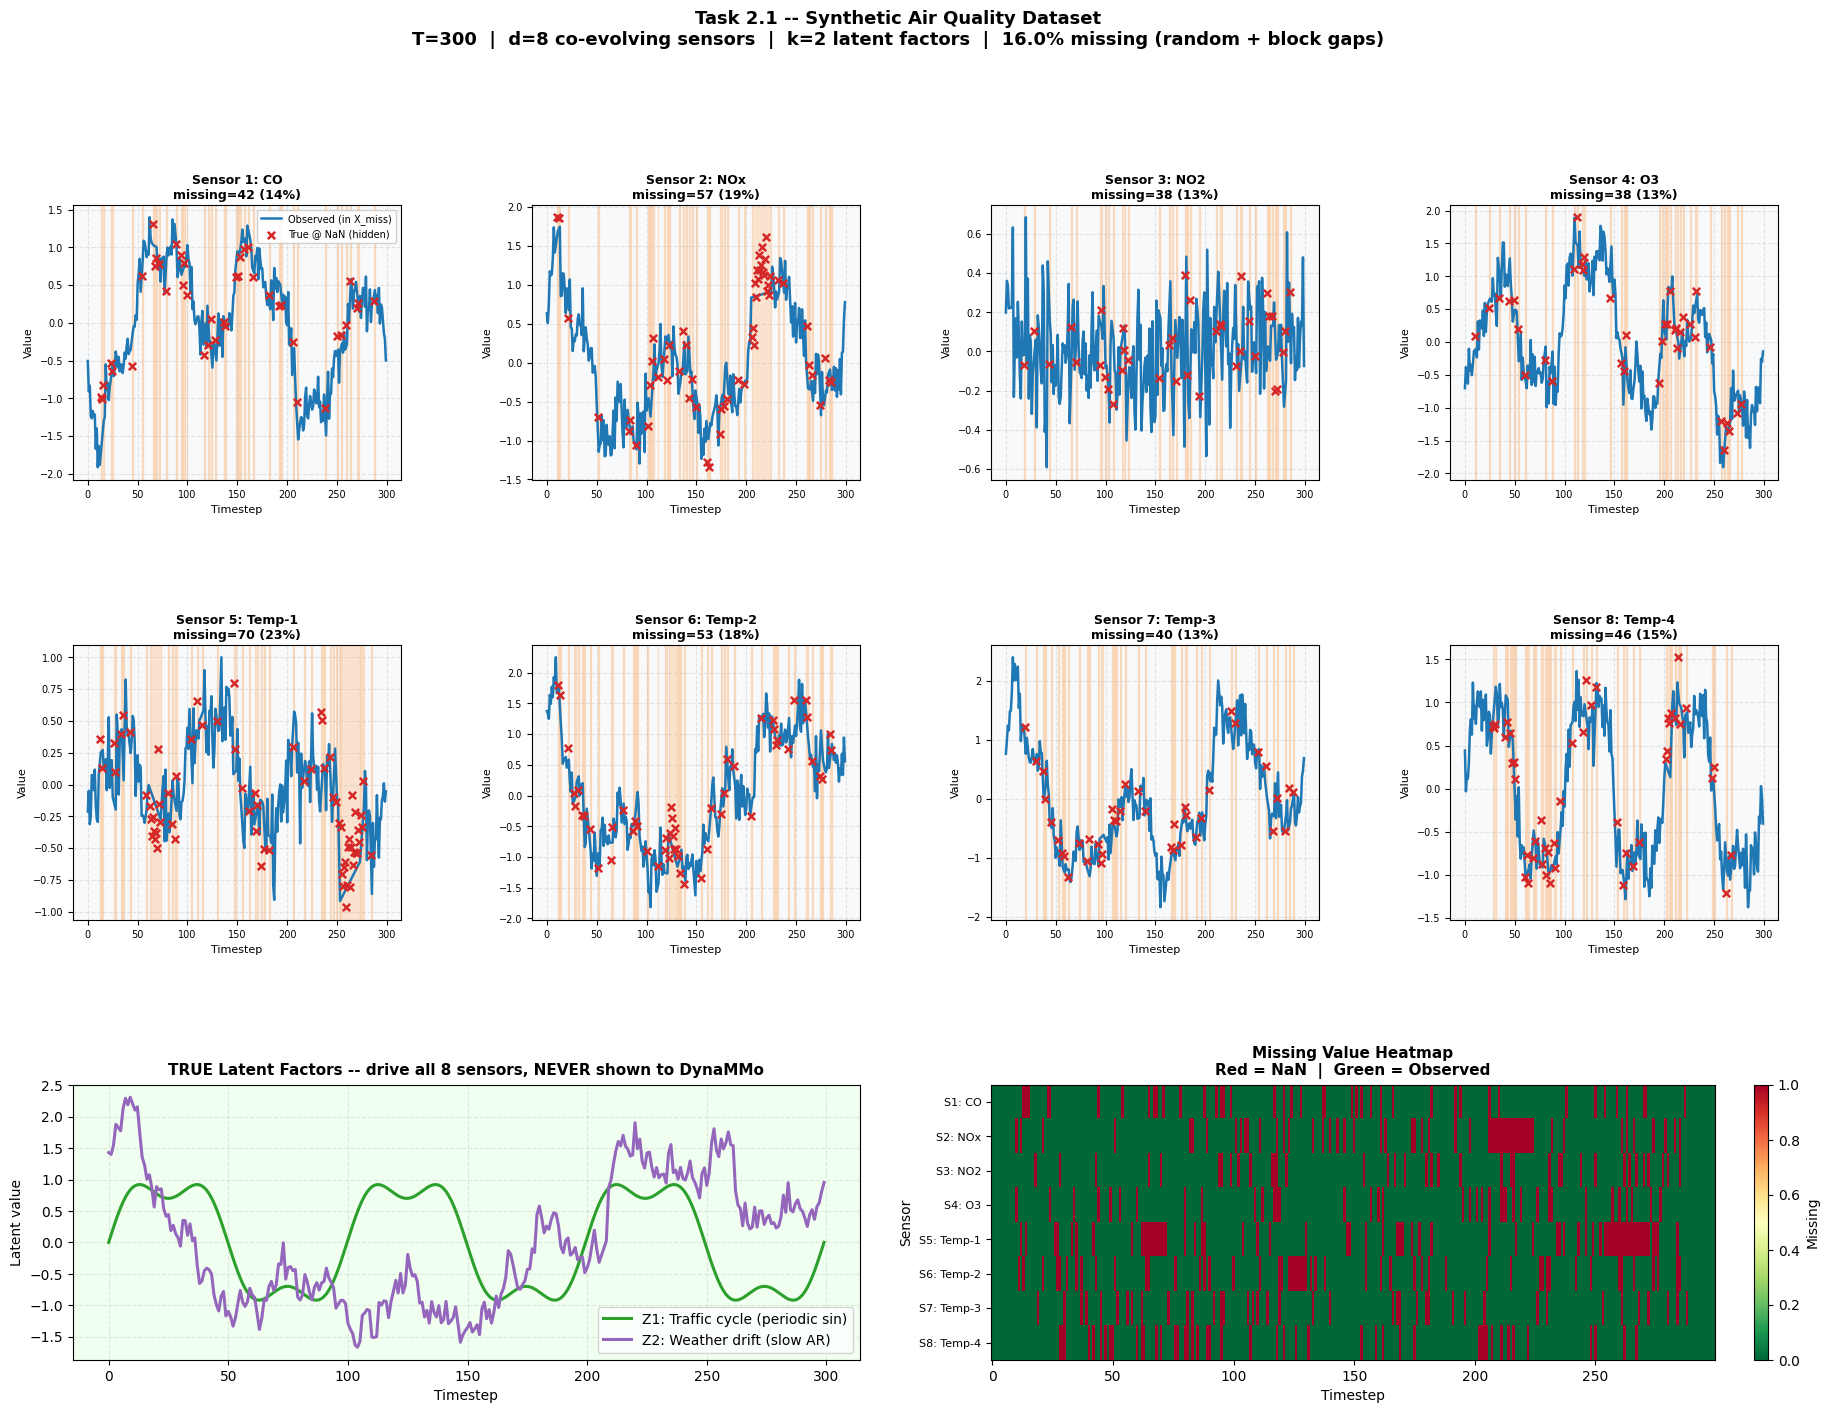

Saved: task2_1_dataset.png


In [4]:
# Cell 4 -- Dataset visualisation
# 3-section figure: 8 sensor traces (rows 1-2), latent factors, missing heatmap
t_ax = np.arange(300)
fig = plt.figure(figsize=(22, 15), facecolor='white')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.60, wspace=0.40)

for i in range(8):
    ax = fig.add_subplot(gs[i//4, i%4])
    obs = ~mm[:,i]
    ax.plot(t_ax[obs], X_true[obs,i], '#1f77b4', lw=1.8,
            label='Observed (in X_miss)', zorder=4)
    miss_t = np.where(mm[:,i])[0]
    ax.scatter(miss_t, X_true[miss_t,i], c='#d62728', s=28, zorder=6,
               marker='x', linewidths=1.8, label='True @ NaN (hidden)')
    in_block=False
    for tv in range(300):
        if mm[tv,i] and not in_block: blk=tv; in_block=True
        elif not mm[tv,i] and in_block:
            ax.axvspan(blk,tv,alpha=0.18,color='#ff7f0e'); in_block=False
    ax.set_title(f'Sensor {i+1}: {SENSOR_NAMES[i]}\nmissing={mm[:,i].sum()} ({mm[:,i].mean()*100:.0f}%)',
                 fontsize=9,fontweight='bold',pad=4)
    ax.set_xlabel('Timestep',fontsize=8); ax.set_ylabel('Value',fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(True,alpha=0.3,ls='--'); ax.set_facecolor('#f8f9fa')
    if i==0: ax.legend(fontsize=7,loc='upper right',framealpha=0.9)

ax_z = fig.add_subplot(gs[2,:2])
ax_z.plot(t_ax,Z_true[:,0],'#2ca02c',lw=2.2,label='Z1: Traffic cycle (periodic sin)')
ax_z.plot(t_ax,Z_true[:,1],'#9467bd',lw=2.2,label='Z2: Weather drift (slow AR)')
ax_z.set_title('TRUE Latent Factors -- drive all 8 sensors, NEVER shown to DynaMMo',
               fontsize=11,fontweight='bold',pad=7)
ax_z.set_xlabel('Timestep',fontsize=10); ax_z.set_ylabel('Latent value',fontsize=10)
ax_z.legend(fontsize=10); ax_z.grid(True,alpha=0.3,ls='--'); ax_z.set_facecolor('#f0fff0')

ax_hm = fig.add_subplot(gs[2,2:])
im=ax_hm.imshow(mm.T,aspect='auto',cmap='RdYlGn_r',interpolation='none',vmin=0,vmax=1)
ax_hm.set_title('Missing Value Heatmap\nRed = NaN  |  Green = Observed',
                fontsize=11,fontweight='bold',pad=7)
ax_hm.set_xlabel('Timestep',fontsize=10); ax_hm.set_ylabel('Sensor',fontsize=10)
ax_hm.set_yticks(range(8))
ax_hm.set_yticklabels([f'S{i+1}: {SENSOR_NAMES[i]}' for i in range(8)],fontsize=8)
plt.colorbar(im,ax=ax_hm,fraction=0.03,label='Missing')

fig.suptitle(f'Task 2.1 -- Synthetic Air Quality Dataset\n'
             f'T=300  |  d=8 co-evolving sensors  |  k=2 latent factors  |  '
             f'{mm.mean()*100:.1f}% missing (random + block gaps)',
             fontsize=13,fontweight='bold',y=1.01)
plt.savefig(os.path.join(RESULTS_DIR,'task2_1_dataset.png'),
            dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('Saved: task2_1_dataset.png')


**Cell 4** — Dataset visualisation:
- **Rows 1-2:** Each of the 8 sensor traces. Blue = observed values seen by model. Red ✕ = true values at NaN positions (hidden from model). Orange bands = missing blocks.
- **Bottom-left:** True latent factors Z₁ (traffic cycle) and Z₂ (weather drift). DynaMMo must recover equivalent structure from `X_miss` alone.
- **Bottom-right:** Missing heatmap — red = NaN, green = observed.

**Paper ref:** Section 2 (Problem Definition), Section 4.1 (Experiments).


## Dataset Justification

**Structure:** Synthetic multivariate time series, T=300, d=8 sensors (CO, NOx, NO2, O3 + 4 temperature channels), k=2 true hidden factors.

**Why valid for DynaMMo:** Satisfies all structural requirements from Paper Section 2 — d co-evolving sequences, k shared latent factors, T≥50, both random and block-structured missing values. Generated by an exact LDS so `X_true` enables precise RMSE evaluation.

**Limitations vs paper:** The paper uses UCI Chlorine (507 sensors, 4310 steps) and CMU Motion Capture (62 joints). Our dataset is smaller with zero model mismatch, so DynaMMo is perfectly specified and shows larger RMSE gains than reported on real data.
